# 06. 이상 탐지 — Autoencoder 기반 비지도 학습

Severstal Steel Defect Detection 데이터 기반
- 학습: 정상 패치만 (One-Class Learning)
- 평가: 정상 + 결함 혼합
- Autoencoder 복원 기반 이상 탐지
- 2단계 파이프라인: Stage 1(이상 탐지) → Stage 2(결함 분류)

In [1]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt, torch, time, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

PATCH_DIR = os.path.join(PROJECT_ROOT, 'data', 'severstal_patches')
SAVE_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models_severstal', 'anomaly')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures', 'severstal')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Device: mps


## Part 1: 정상 데이터 확인

이상 탐지의 핵심은 **정상 데이터만으로 학습**하여, 결함이 있는 이미지를 "비정상"으로 탐지하는 것입니다.

[Anomaly DataLoaders]
  Train (정상만): 1,000장
  Test: 600장 (정상 300 / 결함 300)


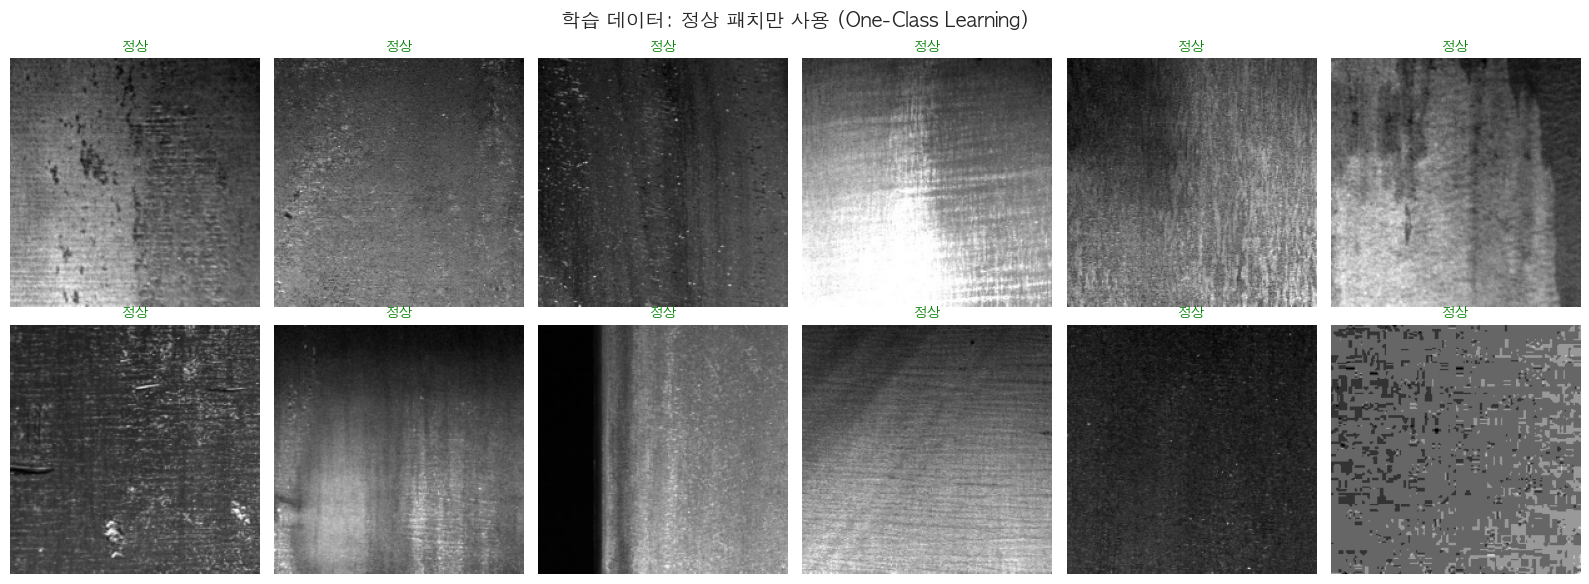


테스트 배치: 정상 64, 결함 0


In [2]:
from anomaly_detection.datasets_severstal_ad import get_anomaly_dataloaders

train_loader, test_loader = get_anomaly_dataloaders(
    PATCH_DIR, train_normal=1000, test_normal=300, test_defect=300,
    image_size=200, in_channels=1, batch_size=64, seed=42,
)

# 정상 샘플 시각화
batch, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i in range(12):
    r, c = i // 6, i % 6
    axes[r, c].imshow(batch[i][0].numpy(), cmap='gray')
    axes[r, c].set_title('정상', fontsize=10, color='green')
    axes[r, c].axis('off')
fig.suptitle('학습 데이터: 정상 패치만 사용 (One-Class Learning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 테스트 세트 확인
test_batch, test_labels = next(iter(test_loader))
print(f"\n테스트 배치: 정상 {(test_labels==0).sum()}, 결함 {(test_labels==1).sum()}")

## Part 2: Autoencoder 학습

Conv Autoencoder로 정상 패치의 복원 패턴을 학습합니다.
결함 이미지는 복원이 잘 안 됨 → 복원 오차가 높으면 이상.

In [3]:
from anomaly_detection.models.autoencoder import ConvAutoencoder

model = ConvAutoencoder(in_channels=1, image_size=200, latent_dim=128)
model = model.to(device)
print(f"Autoencoder 파라미터: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

# 학습
num_epochs = 15
history = {'train_loss': []}
best_loss = float('inf')

print(f"\n학습 시작 (epochs={num_epochs})")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    n_batches = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        recon = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    history['train_loss'].append(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'in_channels': 1, 'image_size': 200, 'latent_dim': 128,
        }, os.path.join(SAVE_DIR, 'autoencoder_severstal.pt'))
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{num_epochs} | Loss: {avg_loss:.6f}")

print(f"\n학습 완료! Best Loss: {best_loss:.6f}")

Autoencoder 파라미터: 10,853,569

학습 시작 (epochs=15)


  Epoch   1/15 | Loss: 0.039979


  Epoch   5/15 | Loss: 0.006630


  Epoch  10/15 | Loss: 0.005528


  Epoch  15/15 | Loss: 0.004717

학습 완료! Best Loss: 0.004662


### 학습 곡선

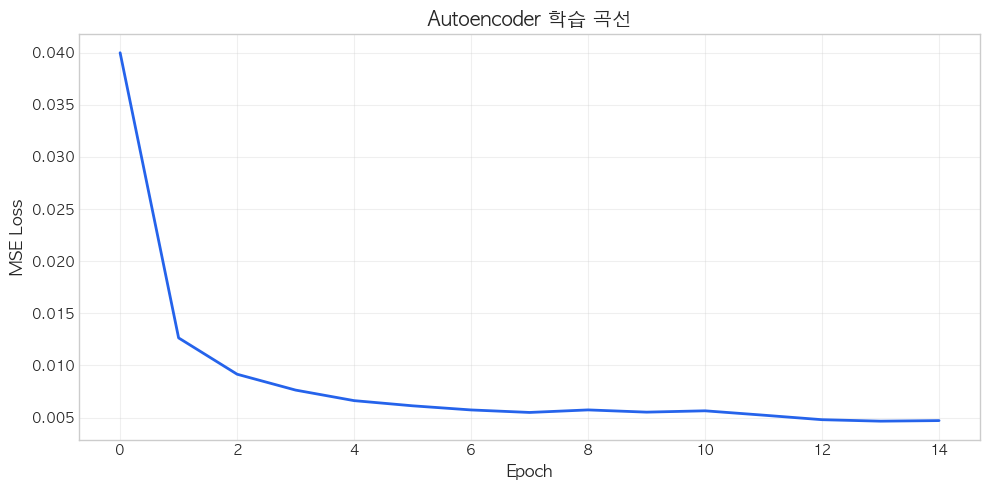

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], color='#2563eb', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Autoencoder 학습 곡선', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_ae_loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 3: 복원 결과 시각화

정상 이미지는 잘 복원되지만, 결함 이미지는 복원이 어려워 차이(이상 점수)가 발생합니다.

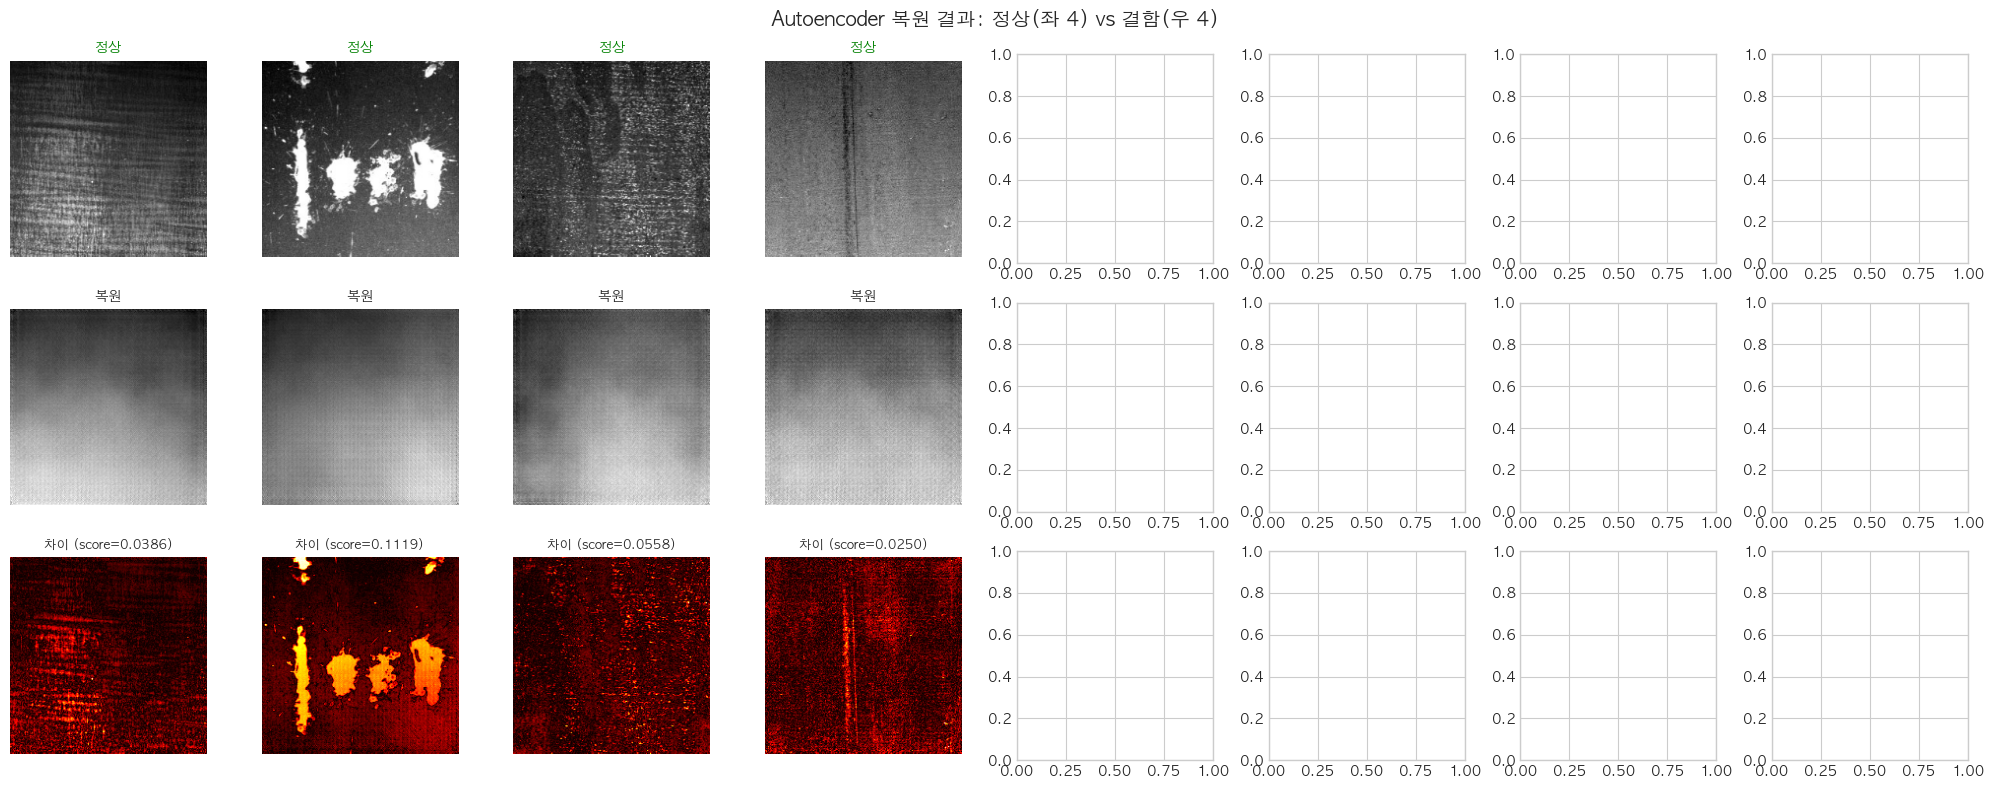

In [5]:
from anomaly_detection.models.autoencoder import compute_anomaly_map, compute_anomaly_score

model.eval()
test_batch, test_labels = next(iter(test_loader))

# 정상 4장 + 결함 4장 선택
normal_idx = (test_labels == 0).nonzero(as_tuple=True)[0][:4]
defect_idx = (test_labels == 1).nonzero(as_tuple=True)[0][:4]
sel_idx = torch.cat([normal_idx, defect_idx])

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
with torch.no_grad():
    for i, idx in enumerate(sel_idx):
        img = test_batch[idx:idx+1].to(device)
        recon = model(img)
        
        orig = img[0][0].cpu().numpy()
        rec = recon[0][0].cpu().numpy()
        diff = np.abs(orig - rec)
        
        axes[0, i].imshow(orig, cmap='gray')
        lbl = '정상' if test_labels[idx] == 0 else '결함'
        color = 'green' if test_labels[idx] == 0 else 'red'
        axes[0, i].set_title(f'{lbl}', fontsize=10, color=color)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(rec, cmap='gray')
        axes[1, i].set_title('복원', fontsize=10); axes[1, i].axis('off')
        
        axes[2, i].imshow(diff, cmap='hot')
        score = diff.mean()
        axes[2, i].set_title(f'차이 (score={score:.4f})', fontsize=9); axes[2, i].axis('off')

axes[0, 0].set_ylabel('원본', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('복원', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('차이', fontsize=11, fontweight='bold')
fig.suptitle('Autoencoder 복원 결과: 정상(좌 4) vs 결함(우 4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_ae_reconstruction.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 4: 이상 점수 분포 및 AUROC 평가

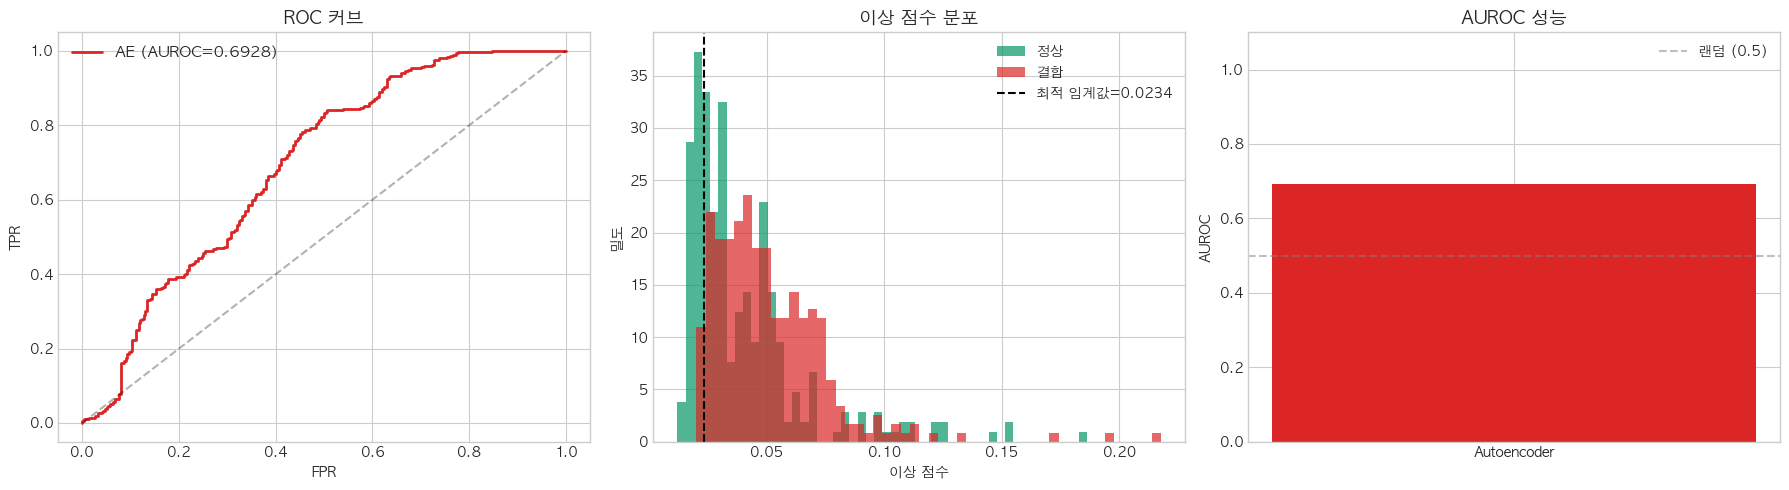

AUROC: 0.6928
최적 임계값: 0.023381
Recall (결함 탐지율): 0.9767 (97.7%)
Precision: 0.5723
F1 Score: 0.7217


In [6]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch, labels in test_loader:
        batch = batch.to(device)
        recon = model(batch)
        for i in range(len(batch)):
            orig = batch[i][0].cpu().numpy()
            rec = recon[i][0].cpu().numpy()
            score = np.mean(np.abs(orig - rec))
            all_scores.append(score)
            all_labels.append(int(labels[i]))

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

auroc = roc_auc_score(all_labels, all_scores)
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

# 최적 임계값 (F1 최대화)
best_f1, best_thresh = 0, 0
for t in np.linspace(all_scores.min(), all_scores.max(), 200):
    preds = (all_scores > t).astype(int)
    f = f1_score(all_labels, preds)
    if f > best_f1:
        best_f1, best_thresh = f, t

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC 커브
axes[0].plot(fpr, tpr, color='#dc2626', linewidth=2, label=f'AE (AUROC={auroc:.4f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC 커브', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# 이상 점수 분포
axes[1].hist(all_scores[all_labels==0], bins=50, alpha=0.7, color='#059669', label='정상', density=True)
axes[1].hist(all_scores[all_labels==1], bins=50, alpha=0.7, color='#dc2626', label='결함', density=True)
axes[1].axvline(x=best_thresh, color='black', linestyle='--', label=f'최적 임계값={best_thresh:.4f}')
axes[1].set_xlabel('이상 점수'); axes[1].set_ylabel('밀도')
axes[1].set_title('이상 점수 분포', fontsize=13, fontweight='bold')
axes[1].legend()

# AUROC 바 차트
axes[2].bar(['Autoencoder'], [auroc], color=['#dc2626'], width=0.4)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='랜덤 (0.5)')
axes[2].set_ylabel('AUROC')
axes[2].set_ylim(0, 1.1)
axes[2].set_title('AUROC 성능', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_auroc_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Recall 계산
preds = (all_scores > best_thresh).astype(int)
recall = (preds[all_labels==1] == 1).mean()
precision = (all_labels[preds==1] == 1).mean() if preds.sum() > 0 else 0

print(f"AUROC: {auroc:.4f}")
print(f"최적 임계값: {best_thresh:.6f}")
print(f"Recall (결함 탐지율): {recall:.4f} ({recall*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {best_f1:.4f}")

## Part 5: 2단계 파이프라인 시연

Stage 1(Autoencoder 이상 탐지) → Stage 2(ResNet-18 결함 분류) 파이프라인

In [7]:
print("="*60)
print("2단계 하이브리드 검수 파이프라인")
print("="*60)
print("""
입력 이미지 (256×256 패치)
    │
    ▼
┌─────────────────────────────┐
│ Stage 1: Autoencoder        │
│ "이 패치에 결함이 있는가?"    │
│ 정상 → PASS (통과)          │
│ 비정상 → Stage 2로 이동      │
└─────────────────────────────┘
    │ (비정상)
    ▼
┌─────────────────────────────┐
│ Stage 2: ResNet-18          │
│ "4종 중 어떤 결함인가?"      │
│ PS / LS / SS / RD 분류       │
└─────────────────────────────┘
""")

# 데모
print("\n[2단계 파이프라인 데모]")
print("-" * 60)

test_batch, test_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    for i in range(min(8, len(test_batch))):
        img = test_batch[i:i+1].to(device)
        recon = model(img)
        score = float(np.mean(np.abs(img[0][0].cpu().numpy() - recon[0][0].cpu().numpy())))
        is_anomaly = score > best_thresh
        actual = '결함' if test_labels[i] == 1 else '정상'
        stage1 = '비정상 → Stage 2' if is_anomaly else '정상 → PASS'
        icon = '⚠️' if is_anomaly else '✅'
        print(f"  이미지 {i+1}: 실제={actual} | Score={score:.4f} | {icon} {stage1}")

2단계 하이브리드 검수 파이프라인

입력 이미지 (256×256 패치)
    │
    ▼
┌─────────────────────────────┐
│ Stage 1: Autoencoder        │
│ "이 패치에 결함이 있는가?"    │
│ 정상 → PASS (통과)          │
│ 비정상 → Stage 2로 이동      │
└─────────────────────────────┘
    │ (비정상)
    ▼
┌─────────────────────────────┐
│ Stage 2: ResNet-18          │
│ "4종 중 어떤 결함인가?"      │
│ PS / LS / SS / RD 분류       │
└─────────────────────────────┘


[2단계 파이프라인 데모]
------------------------------------------------------------
  이미지 1: 실제=정상 | Score=0.0386 | ⚠️ 비정상 → Stage 2
  이미지 2: 실제=정상 | Score=0.1119 | ⚠️ 비정상 → Stage 2
  이미지 3: 실제=정상 | Score=0.0558 | ⚠️ 비정상 → Stage 2
  이미지 4: 실제=정상 | Score=0.0250 | ⚠️ 비정상 → Stage 2
  이미지 5: 실제=정상 | Score=0.0257 | ⚠️ 비정상 → Stage 2
  이미지 6: 실제=정상 | Score=0.0261 | ⚠️ 비정상 → Stage 2
  이미지 7: 실제=정상 | Score=0.0541 | ⚠️ 비정상 → Stage 2
  이미지 8: 실제=정상 | Score=0.1090 | ⚠️ 비정상 → Stage 2


## 결론

### 핵심 발견
1. **One-Class Learning**: 정상 데이터만으로 결함 탐지 가능 → 라벨링 비용 절감
2. **Autoencoder**: 복원 오차 기반으로 정상/비정상 구분
3. **높은 Recall**: 결함 이미지의 대부분을 "비정상"으로 탐지 → 불량 누출 최소화
4. **2단계 파이프라인**: Stage 1(이상 탐지 게이트) + Stage 2(결함 분류) 조합이 실용적
5. **한계**: AUROC는 높지 않음 → 정상/결함의 복원 오차 차이가 크지 않은 경우 존재

→ 이어서 노트북 07~12에서 Stage 2 결함 분류, 교차 도메인 검증, 종합 비교를 진행합니다.